In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/kenya.csv')

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [22]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())

Dataset has 4108 rows and 12 columns

Column names:
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']


In [23]:
df = df.replace(-999, np.nan)

print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [24]:
df['Country'] = 'Kenya'

df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')

df['Month'] = df['Date'].dt.month

df[['YEAR', 'DOY', 'Date', 'Month', 'Country']].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Kenya
1,2015,2,2015-01-02,1,Kenya
2,2015,3,2015-01-03,1,Kenya
3,2015,4,2015-01-04,1,Kenya
4,2015,5,2015-01-05,1,Kenya


In [6]:
df['Country'] = 'Kenya'

In [7]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')

In [8]:
df['Month'] = df['Date'].dt.month

In [9]:
df[['YEAR', 'DOY', 'Date', 'Month', 'Country']].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Kenya
1,2015,2,2015-01-02,1,Kenya
2,2015,3,2015-01-03,1,Kenya
3,2015,4,2015-01-04,1,Kenya
4,2015,5,2015-01-05,1,Kenya


In [25]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(df)}")

Number of duplicate rows: 0


In [26]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [27]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

print("Outliers (|Z| > 3):")
for col in weather_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (abs(z_scores) > 3).sum()
    print(f"{col}: {outliers} outliers")

Outliers (|Z| > 3):
T2M: 7 outliers
T2M_MAX: 3 outliers
T2M_MIN: 9 outliers
PRECTOTCORR: 92 outliers
RH2M: 6 outliers
WS2M: 0 outliers
WS2M_MAX: 6 outliers


In [28]:
monthly_temp = df.groupby('Date')['T2M'].mean()

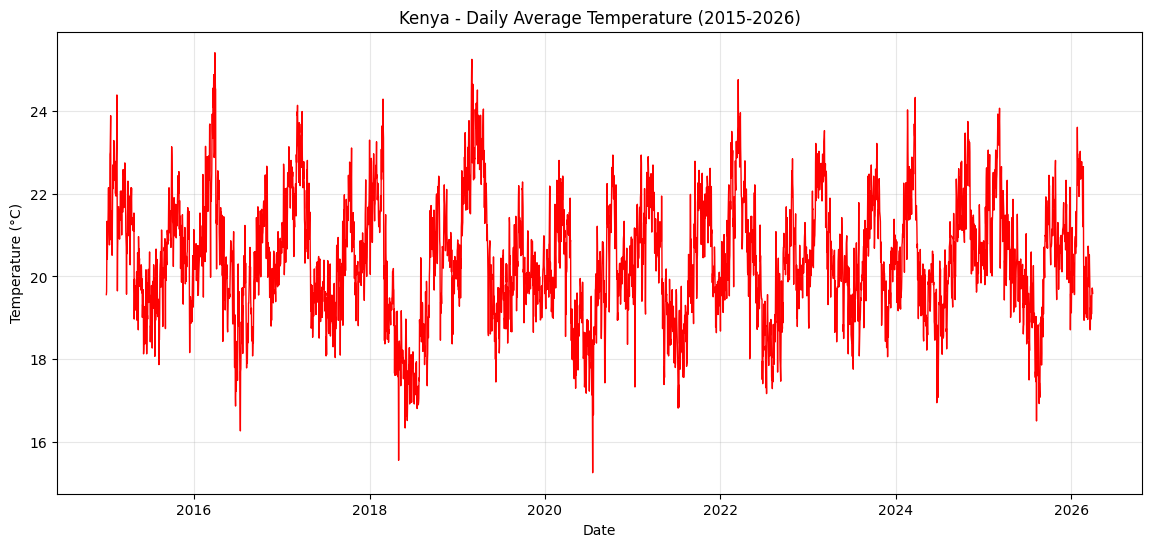

In [29]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index, monthly_temp.values, color='red', linewidth=1)
plt.title('Kenya - Daily Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

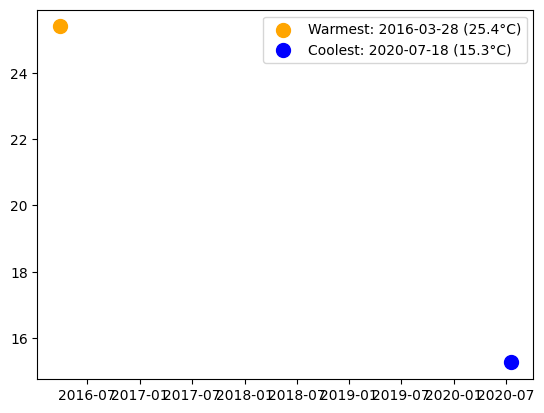

In [30]:
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
plt.scatter(warmest, monthly_temp.max(), color='orange', s=100, 
            label=f'Warmest: {warmest.date()} ({monthly_temp.max():.1f}°C)')
plt.scatter(coolest, monthly_temp.min(), color='blue', s=100, 
            label=f'Coolest: {coolest.date()} ({monthly_temp.min():.1f}°C)')
plt.legend()
plt.show()

In [31]:
monthly_avg = df.groupby('Month')['T2M'].mean()

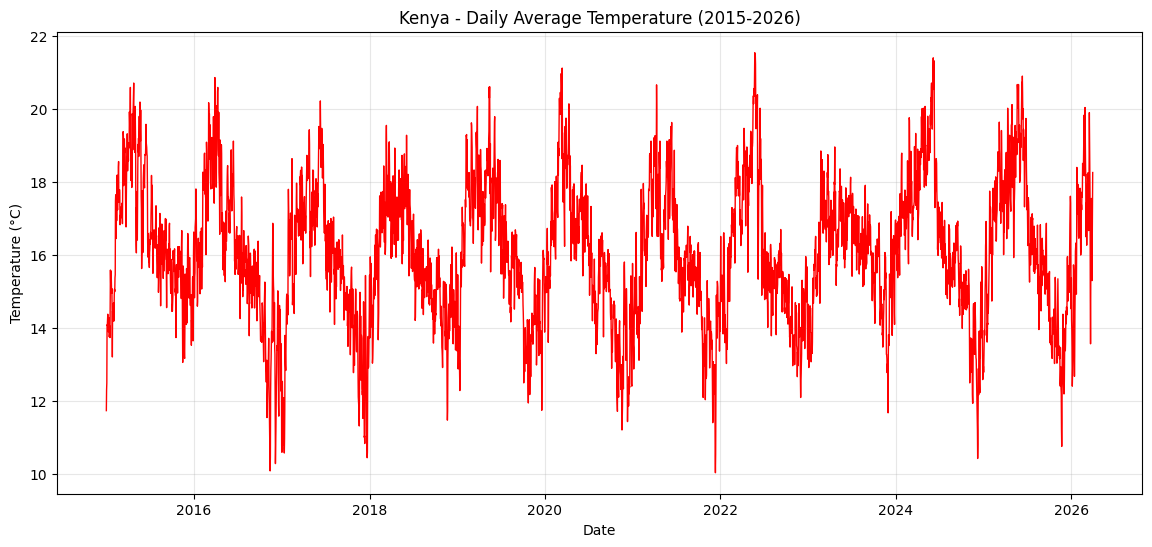

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index, monthly_temp.values, color='red', linewidth=1)
plt.title('Kenya - Daily Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

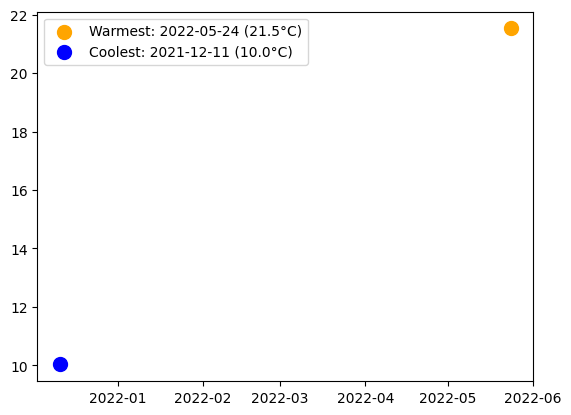

In [16]:
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
plt.scatter(warmest, monthly_temp.max(), color='orange', s=100, 
            label=f'Warmest: {warmest.date()} ({monthly_temp.max():.1f}°C)')
plt.scatter(coolest, monthly_temp.min(), color='blue', s=100, 
            label=f'Coolest: {coolest.date()} ({monthly_temp.min():.1f}°C)')
plt.legend()
plt.show()

In [17]:
monthly_avg = df.groupby('Month')['T2M'].mean()

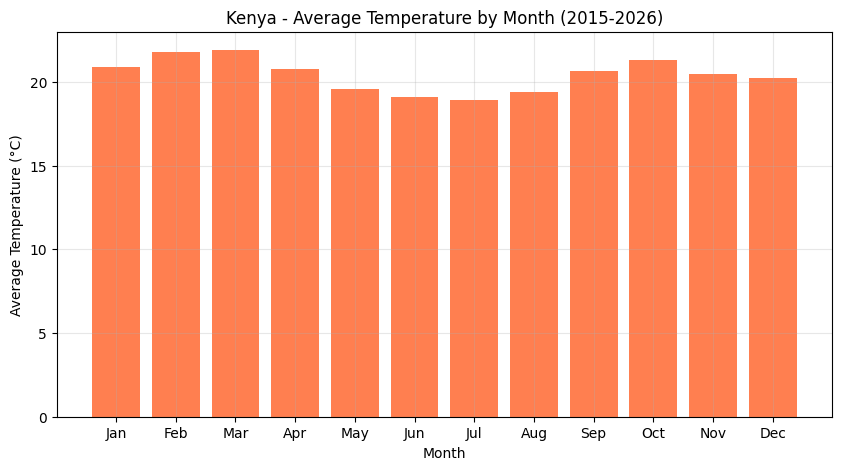

In [32]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='coral')
plt.title('Kenya - Average Temperature by Month (2015-2026)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
print(f"Warmest month: {monthly_avg.idxmax()} ({monthly_avg.max():.1f}°C)")
print(f"Coolest month: {monthly_avg.idxmin()} ({monthly_avg.min():.1f}°C)")

Warmest month: 3 (21.9°C)
Coolest month: 7 (18.9°C)


In [34]:
monthly_rain = df.groupby('Date')['PRECTOTCORR'].sum()

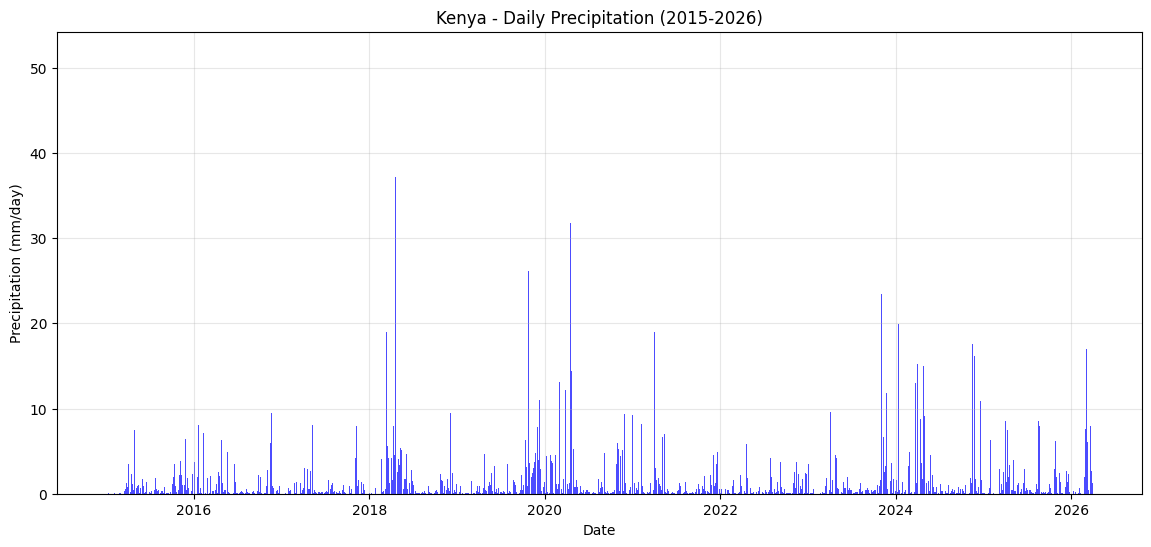

In [35]:
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue', alpha=0.7)
plt.title('Kenya - Daily Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[numeric_cols].corr()


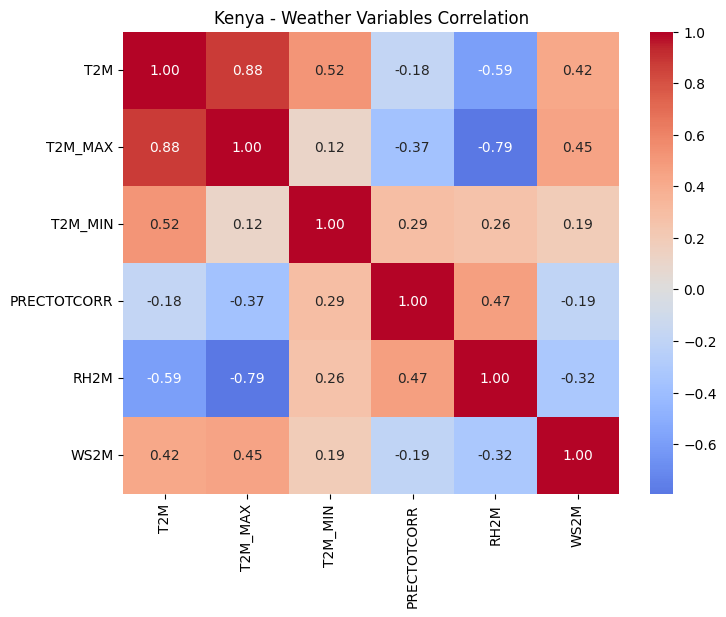

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Kenya - Weather Variables Correlation')
plt.show()

In [38]:
print("Strongest correlations:")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_value:.2f}")

Strongest correlations:
T2M vs T2M_MAX: 0.88
T2M vs T2M_MIN: 0.52
T2M vs RH2M: -0.59
T2M_MAX vs RH2M: -0.79


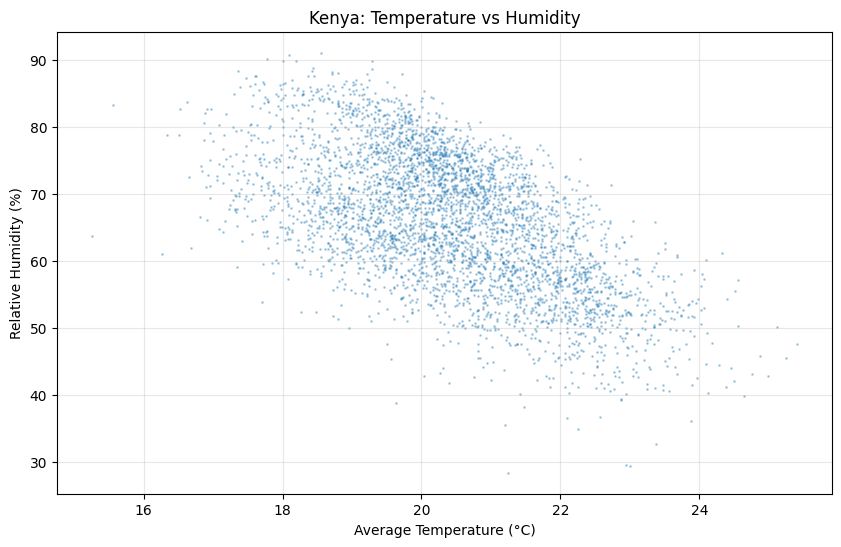

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Kenya: Temperature vs Humidity')
plt.grid(True, alpha=0.3)
plt.show()

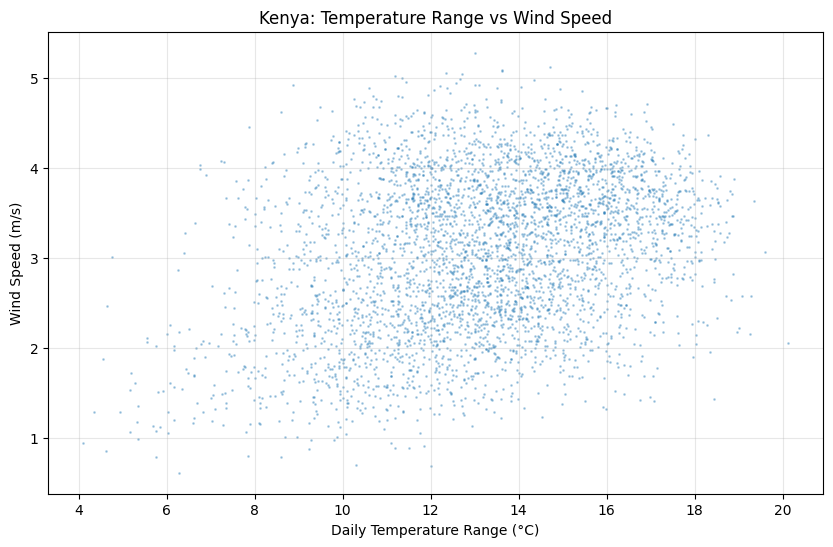

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
plt.xlabel('Daily Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Kenya: Temperature Range vs Wind Speed')
plt.grid(True, alpha=0.3)
plt.show()

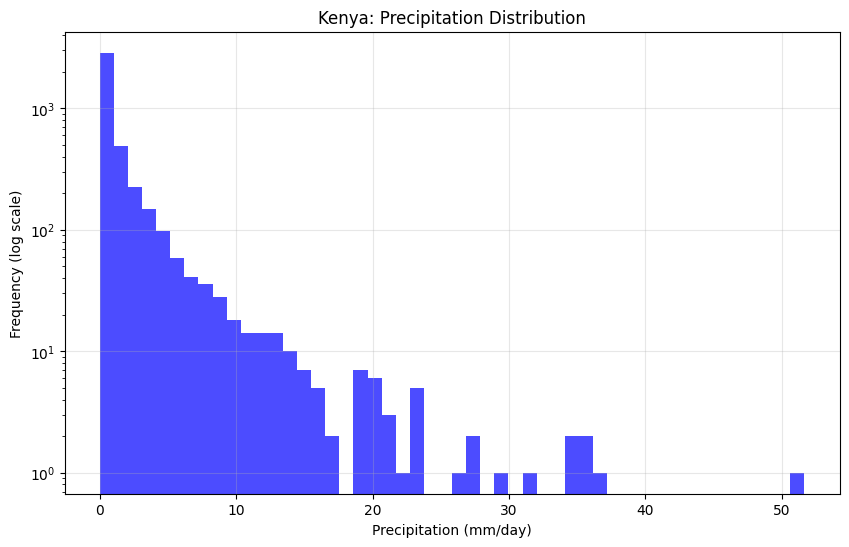

In [41]:
plt.figure(figsize=(10, 6))
plt.hist(df['PRECTOTCORR'], bins=50, alpha=0.7, color='blue')
plt.yscale('log')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Kenya: Precipitation Distribution')
plt.grid(True, alpha=0.3)
plt.show()